<a href="https://colab.research.google.com/github/joashpark/college-football-predictor/blob/main/College_Football_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
## College Football Outcome Prediction Using Elo Ratings and Probabilistic Modeling

### A Data Science Project Using NCAA Game Data (2002–2026)

In [116]:
## Problem Statement

## This project explores whether historical college football performance data can be used to predict game outcomes using statistical and probabilistic modeling techniques.

In [117]:
## Data Overview

#- Source: NCAA game dataset (2002–2026)
#- Each row represents one game
#- Includes scores, rankings, conferences, and team statistics

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [119]:
import pandas as pd

df = pd.read_csv("cfb_box-scores_2002-2025.csv")

In [120]:
df.head()

,season,week,date,time_et,game_type,away,home,rank_away,rank_home,conf_away,...,int_away,int_home,pen_num_away,pen_yards_away,pen_num_home,pen_yards_home,possession_away,possession_home,attendance,tv
0,2002,1.0,2002-08-22,7:30 PM,regular,Colorado State,Virginia,NaN,NaN,mwc,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57120.0,NaN
1,2002,1.0,2002-08-23,8:00 PM,regular,Fresno State,Wisconsin,NaN,25.0,wac,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75136.0,NaN
2,2002,1.0,2002-08-24,2:30 PM,regular,Texas Tech,Ohio State,NaN,13.0,big12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100037.0,NaN
3,2002,1.0,2002-08-24,4:30 PM,regular,New Mexico,NC State,NaN,NaN,mwc,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47018.0,NaN
4,2002,1.0,2002-08-24,7:45 PM,regular,Arizona State,Nebraska,NaN,10.0,pac12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77779.0,NaN


In [121]:
df.columns

Index(['season', 'week', 'date', 'time_et', 'game_type', 'away', 'home',
       'rank_away', 'rank_home', 'conf_away', 'conf_home', 'neutral',
       'score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away',
       'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home',
       'first_downs_away', 'first_downs_home', 'third_down_comp_away',
       'third_down_att_away', 'third_down_comp_home', 'third_down_att_home',
       'fourth_down_comp_away', 'fourth_down_att_away',
       'fourth_down_comp_home', 'fourth_down_att_home', 'pass_comp_away',
       'pass_att_away', 'pass_yards_away', 'pass_comp_home', 'pass_att_home',
       'pass_yards_home', 'rush_att_away', 'rush_yards_away', 'rush_att_home',
       'rush_yards_home', 'total_yards_away', 'total_yards_home', 'fum_away',
       'fum_home', 'int_away', 'int_home', 'pen_num_away', 'pen_yards_away',
       'pen_num_home', 'pen_yards_home', 'possession_away', 'possession_home',
       'attendance', 'tv'],
      dt

In [122]:
#3. Feature Engineering

In [123]:
df['home_win'] = (df['score_home'] > df['score_away']).astype(int)

In [124]:
home_win_rate = df['home_win'].mean()
print(home_win_rate)
home_advantage = df['score_home'].sub(df['score_away']).mean()
print(home_advantage)

0.6234944312855919
7.232878093030288


In [125]:
df['recency_weight'] = df['season'] - df['season'].min() + 1
home = df[['home', 'score_home', 'score_away', 'recency_weight']].copy()
away = df[['away', 'score_away', 'score_home', 'recency_weight']].copy()

home.columns = ['team', 'points_for', 'points_against', 'weight']
away.columns = ['team', 'points_for', 'points_against', 'weight']

teams = pd.concat([home, away])


In [126]:
#4. Model Development

In [127]:
teams_list = pd.concat([df['home'], df['away']]).unique()
ratings = {team: 1500 for team in teams_list}

In [128]:

opponent_strength = {}

In [129]:
K = 20

for _, row in df.iterrows():
    home = row['home']
    away = row['away']

    weight = row['recency_weight']

    home_rating = ratings[home]
    away_rating = ratings[away]

    expected_home = 1 / (1 + 10 ** ((away_rating - home_rating) / 400))
    actual_home = row['home_win']

    ratings[home] += K * weight * (actual_home - expected_home)
    ratings[away] += K * weight * ((1 - actual_home) - (1 - expected_home))

In [130]:
team_ratings = teams.groupby('team').apply(
    lambda x: ( (x['points_for'] - x['points_against']) * x['weight'] ).sum() / x['weight'].sum(),
    include_groups=False
)

In [131]:
home_advantage = (df['score_home'] - df['score_away']).mean()

In [132]:
conf_strength = df.groupby('conf_home')['home_win'].mean()

In [133]:
import numpy as np

def win_probability(home_team, away_team):
    diff = (team_ratings[home_team] + home_advantage) - team_ratings[away_team]
    return 1 / (1 + np.exp(-diff))

In [134]:
def predict(home, away):
    home_rating = ratings[home]
    away_rating = ratings[away]

    home_conf = conf_adjust(df[df['home'] == home]['conf_home'].iloc[0])
    away_conf = conf_adjust(df[df['away'] == away]['conf_away'].iloc[0])

    adjusted_home = home_rating + (home_conf - 0.5) * 50
    adjusted_away = away_rating + (away_conf - 0.5) * 50

    prob = 1 / (1 + 10 ** ((adjusted_away - adjusted_home) / 400))

    return home if prob > 0.5 else away

In [135]:
import random

def simulate_game(home, away):
    prob = 1 / (1 + 10 ** ((ratings[away] - ratings[home]) / 400))
    return home if random.random() < prob else away

In [136]:
def conf_adjust(team_conf):
    return conf_strength.get(team_conf, 0.5)

In [137]:
#5. Model Evaluation

In [150]:
df['prediction'] = df.apply(
    lambda row: predict(row['home'], row['away']),
    axis=1
)

df['actual_winner'] = df.apply(
    lambda row: row['home'] if row['home_win'] == 1 else row['away'],
    axis=1
)

df['correct'] = df['prediction'] == df['actual_winner']

accuracy = df['correct'].mean()
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6197147608728519


In [142]:
df['predicted_prob'] = df.apply(
    lambda row: win_probability(row['home'], row['away']),
    axis=1
)

df['upset'] = (
    (df['home_win'] == 1) & (df['predicted_prob'] < 0.5)
) | (
    (df['home_win'] == 0) & (df['predicted_prob'] > 0.5)
)

In [ ]:
#6. Results and Visualization

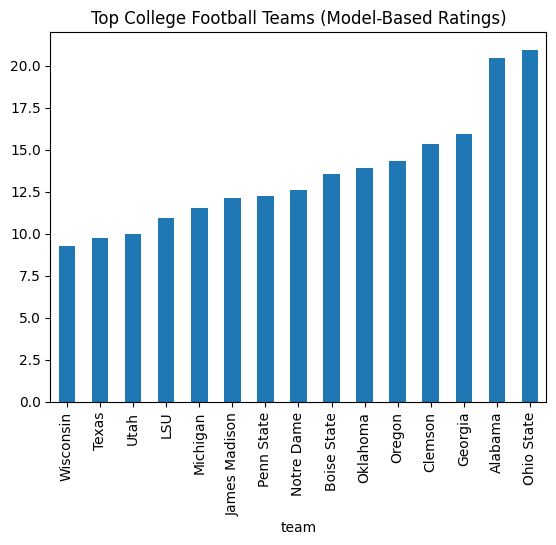

In [143]:
import matplotlib.pyplot as plt

team_ratings.sort_values().tail(15).plot(kind='bar')
plt.title("Top College Football Teams (Model-Based Ratings)")
plt.show()

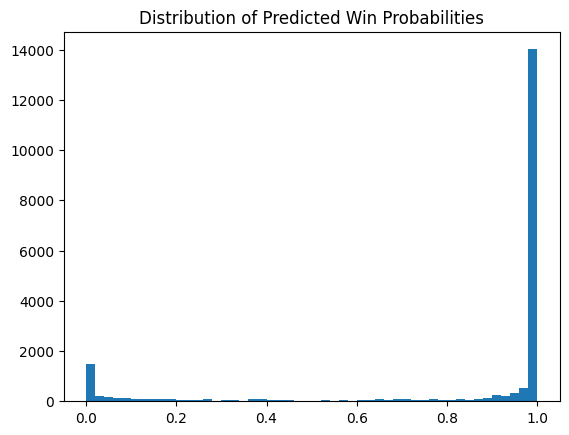

In [145]:
import matplotlib.pyplot as plt

plt.hist(df['predicted_prob'], bins=50)
plt.title("Distribution of Predicted Win Probabilities")
plt.show()

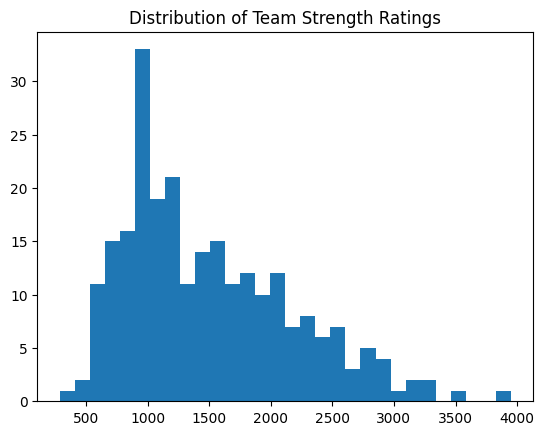

In [146]:
import matplotlib.pyplot as plt

plt.hist(list(ratings.values()), bins=30)
plt.title("Distribution of Team Strength Ratings")
plt.show()

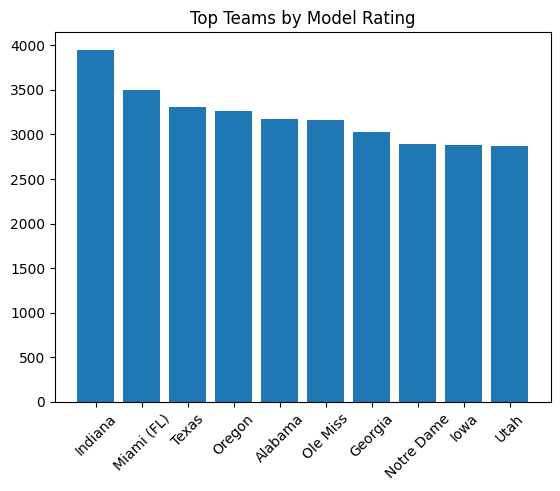

In [147]:
top_teams = sorted(ratings.items(), key=lambda x: x[1], reverse=True)[:10]

names = [t[0] for t in top_teams]
values = [t[1] for t in top_teams]

plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("Top Teams by Model Rating")
plt.show()

In [148]:
wins = {}

for team in teams_list:
    wins[team] = 0

for _, row in df.sample(500).iterrows():  # sample for speed
    winner = simulate_game(row['home'], row['away'])
    wins[winner] += 1


In [149]:
sorted(wins.items(), key=lambda x: x[1], reverse=True)[:10]

[('BYU', 11),
 ('Western Michigan', 10),
 ('Navy', 10),
 ('Texas Tech', 10),
 ('Troy', 10),
 ('Toledo', 9),
 ('Indiana', 9),
 ('Iowa State', 8),
 ('Alabama', 8),
 ('Texas', 8)]

In [ ]:
#7. Season and Playoff Simulation

In [154]:
season_wins = {team: 0 for team in teams_list}

for _, row in df.iterrows():
    winner = simulate_game(row['home'], row['away'])
    season_wins[winner] += 1

In [155]:
playoff_teams = sorted(season_wins.items(), key=lambda x: x[1], reverse=True)[:4]
playoff_teams = [team[0] for team in playoff_teams]

In [156]:
def playoff_game(team1, team2):
    prob = win_probability(team1, team2)
    return team1 if random.random() < prob else team2

In [157]:
semi1_winner = playoff_game(playoff_teams[0], playoff_teams[3])
semi2_winner = playoff_game(playoff_teams[1], playoff_teams[2])

In [158]:
champion = playoff_game(semi1_winner, semi2_winner)

print("Playoff Teams:", playoff_teams)
print("Champion:", champion)

Playoff Teams: ['Miami (FL)', 'Georgia', 'Texas', 'Oregon']
Champion: Miami (FL)
